## IMPORTS

In [1]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns

from scipy.stats import pearsonr
from shapely.ops import linemerge
from matplotlib.patches import Patch
from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial


MARKOV_STEPS = 1000

## READING DATA

In [2]:
highways = gpd.read_file("data/Highways%3A_Traffic_Counts/Highways%3A_Traffic_Counts.shp")
major_roads = gpd.read_file("data/Major_Roads/Major_Roads.shp")
vtds = gpd.read_file("data/census_vtds/co.shp")
cois = gpd.read_file("data/Colorado_communities.geojson")
congressional_2021 = gpd.read_file("data/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_w_Final_Adjustments.shp")


## HELPER FUNCTIONS

In [3]:
def get_road_stats(road_json):
    lats, lons, routes, aadts = [], [], [], []
    for geom, route in zip(road_json.geometry, road_json.get('ROUTE', road_json.index)):
        # Handle LineStrings and MultiLineStrings
        for line in (geom.geoms if geom.geom_type == 'MultiLineString' else [geom]):
            x, y = line.xy
            lons.extend(list(x) + [None])
            lats.extend(list(y) + [None])
            routes.extend([route] * (len(x) + 1))

    for geom, aadt in zip(high_ways.geometry, high_ways.get('AADT', high_ways.index)):
        # Handle LineStrings and MultiLineStrings
        for line in (geom.geoms if geom.geom_type == 'MultiLineString' else [geom]):
            x, y = line.xy
            aadts.extend([aadt] * (len(x) + 1))
    return lats, lons, routes, aadts

def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)
    
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

def merge_lines(geoms):
    # joining continous roads
    merged = linemerge(geoms.tolist()) 
    return merged

def calculate_ir(partiton):
    # gets the districts for each precinct
    vtds["district"] = vtds.index.map(partiton.assignment)

    #gets a set of unique districts to iterate through
    unique_districts = set(partiton.assignment.values())

    #total_intra_score: the travel within a district, total_inter_score: travel between districts
    total_intra_score = 0
    total_inter_score = 0

    #loops through each district in a partition
    for dist_id in unique_districts:

        # gets the district shape
        dist_gdf = vtds[vtds["district"] == dist_id]
        # joins the major_roads and district into one dataframe
        com_roads = gpd.sjoin(major_roads, dist_gdf)

        # dissolves the com_roads dataframe to columns we actually care about (AADT)
        dissolved_gdf = com_roads.dissolve(
            by='ROUTE', 
            aggfunc={'AADT': 'mean'}
        ).reset_index()

        #
        single_poly = dist_gdf.geometry.union_all()

        #produces a dataframe to see with roads are fully within a district
        dissolved_gdf['fully_within'] = dissolved_gdf.geometry.within(single_poly)

        intra_roads = dissolved_gdf[dissolved_gdf['fully_within'] == True]
        inter_roads = dissolved_gdf[dissolved_gdf['fully_within'] == False]

        #add the current districts intra/inter scores to the total
        total_intra_score += intra_roads['AADT'].mean()
        total_inter_score += inter_roads['AADT'].mean()
    #once we loop through all districts we get IR by dividing the intra over the inter    
    final_ir = total_intra_score/total_inter_score
    return final_ir

## GIVING COIS POPULATION FROM VTDS

In [4]:
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

vtds['TOTVOTES20'] = vtds['PRE20D'] + vtds['PRE20R'] + vtds['PRE20O']


vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

clean_overlaps['coi_pop'] = clean_overlaps['TOTVOTES20'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['entry_ID']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk


vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]

C:\Users\gislab\AppData\Local\Temp\ipykernel_8520\4253241745.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vtds['vtd_area'] = vtds.geometry.area
C:\Users\gislab\AppData\Local\Temp\ipykernel_8520\4253241745.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']


## CONGRESSIONAL MAP

In [5]:
congressional_2021 = congressional_2021.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2021 = gpd.sjoin(vtd_points, congressional_2021, how="left", predicate="intersects")

vtds['district_2021'] = joined_vtds_2021['District']

## GETTING INITIAL PARTITION

In [6]:
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# Colorado has 35 state senate districts
total_population = sum(node.get('TOTVOTES20', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTVOTES20", 
    epsilon=0.05
)

initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        #'ir': calculate_ir
    }
)

df = extract_data(initial_partition)

community_scores_df = score_communities(df)


cois_enriched = cois.merge(
        community_scores_df[['community_id', 'sss_score', 'total_pop']], 
        left_on='entry_ID', 
        right_on='community_id', 
        how='left'
    )
cois_enriched['sss_score'] = cois_enriched['sss_score'].fillna(0)
cois_enriched['total_pop'] = cois_enriched['total_pop'].fillna(0)

c:\Users\gislab\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


## STATIC MAP

In [7]:
'''
if cois_enriched.crs != high_ways.crs:
    cois_enriched = cois_enriched.to_crs(high_ways.crs)


fig, ax = plt.subplots(figsize=(12, 10))

#cois.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")
#vtds.plot(ax=ax, color="white", edgecolor="lightpink", linewidth=0.5, label = 'vtds')
high_ways.plot(ax=ax, color="black", linewidth=1, label = 'highways')
cois_enriched.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")
#major_roads.plot(ax=ax, color="grey", linewidth=0.7, label = 'major_roads')

ax.set_title("Colorado Road Traffic", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()
'''

'\nif cois_enriched.crs != high_ways.crs:\n    cois_enriched = cois_enriched.to_crs(high_ways.crs)\n\n\nfig, ax = plt.subplots(figsize=(12, 10))\n\n#cois.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")\n#vtds.plot(ax=ax, color="white", edgecolor="lightpink", linewidth=0.5, label = \'vtds\')\nhigh_ways.plot(ax=ax, color="black", linewidth=1, label = \'highways\')\ncois_enriched.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")\n#major_roads.plot(ax=ax, color="grey", linewidth=0.7, label = \'major_roads\')\n\nax.set_title("Colorado Road Traffic", fontsize=14)\nax.legend()\nax.axis("off")\nplt.show()\n'

## INTERACTIVE MAP

In [8]:
# CONVERSIONS FOR PLOTLY
'''
vtds_4326 = vtds.to_crs(epsg=4326)
cois_4326 = cois_enriched.to_crs(epsg=4326)
#major_roads_4326 = major_roads.to_crs(epsg=4326)

vtds_geojson = json.loads(vtds_4326.to_json())
cois_geojson = json.loads(cois_4326.to_json())
#major_roads_geojson = json.loads(major_roads_4326.to_json())

minx, miny, maxx, maxy = vtds_4326.total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

fig = go.Figure()

# COI TRACE
coi_colors = cois_4326["entry_name"].astype("category").cat.codes
custom_data = np.stack((cois['population'], cois['entry_name']), axis=-1)

hover_template = (
    "<b>Population:</b> %{customdata[0]}<br>"
    "<b>Entry Name:</b> %{customdata[1]}"
    "<extra></extra>"
)


fig.add_trace(
    go.Choroplethmap(
        geojson=cois_geojson,
        locations=cois_4326.index,
        z=coi_colors,
        customdata=custom_data,
        #text=cois_4326["entry_name"],  
        colorscale="Viridis",
        showscale=True,
        marker=dict(opacity=0.5, line=dict(width=0.5, color="black")),
        hovertemplate=hover_template
        #hovertemplate="<b>Cluster Name:</b> %{text}<extra></extra>",
    )
)


h_lats, h_lons, h_routes, h_aadts = get_road_stats(high_ways)
print(len(h_lats))


custom_data2 = np.stack((h_routes, h_aadts), axis=-1)
hover_template2 = (
    "<b>Route #:</b> %{customdata[0]}<br>"
    "<b>AADT:</b> %{customdata[1]}"
    "<extra></extra>"
)

# HIGHWAYS TRACE
fig.add_trace(go.Scattermap(
    lon=h_lons,
    lat=h_lats,  
    mode='lines',
    line=dict(width=1.5, color='black'),
    customdata=custom_data2,
    name='highways',
    showlegend=True,
    hovertemplate= hover_template2
))



m_lats, m_lons, m_routes, m_aadts = get_road_stats(major_roads)

# MAJOR ROADS TRACE

fig.add_trace(go.Scattermap(
    lon=m_lons,
    lat=m_lats,
    #customdata = custom_data3,
    mode='lines',
    line=dict(width=0.5, color='black'),
    name='highways',
    showlegend=True,
    visible=False
    #hover_template3 = hover_template3

    #hovertemplate= "<b>MR Route #:</b> %{text}<extra></extra>"
))


# build the toggle menu
updatemenus = [
        dict(
            type="buttons",
            direction="right",
            active=0,
            x=0.5,
            y=1.05,
            xanchor="center",
            yanchor="bottom",
            buttons=list([
                dict(
                    label="Highways Map",
                    method="update",
                    # trace index as args
                    args=[{"visible": [True, True, False]}]
                ),
                dict(
                    label="Major Road Map",
                    method="update",
                    # hides trace 0 and 1, shows trace 2
                    args=[{"visible": [True, False, True]}]
                )
            ]),
        )
]

fig.update_layout(
    title="Colorado's Interactive Aggregated Communities and Roads Map",
    updatemenus=updatemenus,
    map_style="open-street-map",
    map_zoom=6,
    map_center={"lat": center_lat, "lon": center_lon},
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    height=800,
    clickmode="event+select" 
)

fig.show()
'''



'\nvtds_4326 = vtds.to_crs(epsg=4326)\ncois_4326 = cois_enriched.to_crs(epsg=4326)\n#major_roads_4326 = major_roads.to_crs(epsg=4326)\n\nvtds_geojson = json.loads(vtds_4326.to_json())\ncois_geojson = json.loads(cois_4326.to_json())\n#major_roads_geojson = json.loads(major_roads_4326.to_json())\n\nminx, miny, maxx, maxy = vtds_4326.total_bounds\ncenter_lat = (miny + maxy) / 2\ncenter_lon = (minx + maxx) / 2\n\nfig = go.Figure()\n\n# COI TRACE\ncoi_colors = cois_4326["entry_name"].astype("category").cat.codes\ncustom_data = np.stack((cois[\'population\'], cois[\'entry_name\']), axis=-1)\n\nhover_template = (\n    "<b>Population:</b> %{customdata[0]}<br>"\n    "<b>Entry Name:</b> %{customdata[1]}"\n    "<extra></extra>"\n)\n\n\nfig.add_trace(\n    go.Choroplethmap(\n        geojson=cois_geojson,\n        locations=cois_4326.index,\n        z=coi_colors,\n        customdata=custom_data,\n        #text=cois_4326["entry_name"],  \n        colorscale="Viridis",\n        showscale=True,\n     

## ENACTED PARTITION

In [9]:

enacted_2021 = Partition(
    g,
    assignment="district_2021",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'ir': calculate_ir
    }
)

print(enacted_2021)

<Partition [8 parts]>


## DEBUGGING

In [10]:
## IR SCORE

if vtds.crs != major_roads.crs:
    major_roads = major_roads.to_crs(vtds.crs)
'''

vtds["district"] = vtds.index.map(enacted_2021.assignment)

unique_districts = set(enacted_2021.assignment.values())
total_intra_score = 0
total_inter_score = 0

for dist_id in unique_districts:

    dist_gdf = vtds[vtds["district"] == dist_id]
    com_roads = gpd.sjoin(major_roads, dist_gdf)

    dissolved_gdf = com_roads.dissolve(
        by='ROUTE', 
        aggfunc={'AADT': 'mean'}
    ).reset_index()

    # 1. Dissolve the polygon dataframe into a single geometry to compare against all roads
    # (Skip this step if polygon_gdf is already a single, dissolved row)
    single_poly = dist_gdf.geometry.union_all()

    # 2. Check which road lines are completely inside the polygon
    dissolved_gdf['fully_within'] = dissolved_gdf.geometry.within(single_poly)

    # 3. Filter the GeoDataFrame to keep only lines fully in the polygon
    intra_roads = dissolved_gdf[dissolved_gdf['fully_within'] == True]
    inter_roads = dissolved_gdf[dissolved_gdf['fully_within'] == False]

    total_intra_score += intra_roads['AADT'].mean()
    total_inter_score += inter_roads['AADT'].mean()
    
    
    fig, ax = plt.subplots(figsize=(8, 8))
        
    dist_gdf.plot(ax=ax, color="blue", edgecolor="black")
    intra_roads.plot(ax=ax, color='crimson', linewidth=1.5, label='Filtered Roads')
        
    ax.set_title(f"District {dist_id} Map", fontsize=14)
    ax.set_axis_off()

    fig, ax = plt.subplots(figsize=(8, 8))
        
    dist_gdf.plot(ax=ax, color="blue", edgecolor="black")
    inter_roads.plot(ax=ax, color='crimson', linewidth=1.5, label='Filtered Roads')
        
    ax.set_title(f"District {dist_id} Map", fontsize=14)
    ax.set_axis_off()
    
    #ind_ir = intra_roads_val/inter_roads_val
    #print(ind_ir)
    
final_ir = total_intra_score/total_inter_score
print(f"final IR = {final_ir}")
'''

'''
vtds["district"] = vtds.index.map(enacted_2021.assignment)
    
    # 2. Dissolve VTDs by district once to get the total shape of each district
    # This replaces doing it per-iteration and running union_all()
districts_gdf = vtds.dissolve(by="district").reset_index()
    
    # 3. Find roads *fully within* any district using a global spatial join
    # 'predicate="within"' ensures the road geometry is completely inside the district
intra_roads_mapped = gpd.sjoin(major_roads, districts_gdf, how="inner", predicate="within")
    
    # 4. Find *all* roads touching/intersecting districts (for the inter-district calculation)
all_roads_mapped = gpd.sjoin(major_roads, districts_gdf, how="inner", predicate="intersects")
    
    # 5. Identify inter_roads (they intersect a district but are NOT fully within it)
    # We can find these by looking at the roads in all_roads_mapped that aren't in intra_roads_mapped
    # A cleaner way using pandas is tracking the index of major_roads
intra_indices = set(intra_roads_mapped.index)
    
    # Filter all_roads_mapped to get only inter_roads
inter_roads_mapped = all_roads_mapped[~all_roads_mapped.index.isin(intra_indices)]
    
    # 6. Group and average AADT per Route per District
    # This replicates your dissolve(by='ROUTE', aggfunc={'AADT': 'mean'}) logic globally
intra_grouped = intra_roads_mapped.groupby(['district', 'ROUTE'])['AADT'].mean().reset_index()
inter_grouped = inter_roads_mapped.groupby(['district', 'ROUTE'])['AADT'].mean().reset_index()
    
    # 7. Calculate the final means per district
    # Replicates: intra_roads['AADT'].mean()
intra_dist_means = intra_grouped.groupby('district')['AADT'].mean()
inter_dist_means = inter_grouped.groupby('district')['AADT'].mean()
    
    # 8. Sum up the scores across all districts and return IR
total_intra_score = intra_dist_means.sum()
total_inter_score = inter_dist_means.sum()
    
print(total_intra_score / total_inter_score)
'''

'\nvtds["district"] = vtds.index.map(enacted_2021.assignment)\n\n    # 2. Dissolve VTDs by district once to get the total shape of each district\n    # This replaces doing it per-iteration and running union_all()\ndistricts_gdf = vtds.dissolve(by="district").reset_index()\n\n    # 3. Find roads *fully within* any district using a global spatial join\n    # \'predicate="within"\' ensures the road geometry is completely inside the district\nintra_roads_mapped = gpd.sjoin(major_roads, districts_gdf, how="inner", predicate="within")\n\n    # 4. Find *all* roads touching/intersecting districts (for the inter-district calculation)\nall_roads_mapped = gpd.sjoin(major_roads, districts_gdf, how="inner", predicate="intersects")\n\n    # 5. Identify inter_roads (they intersect a district but are NOT fully within it)\n    # We can find these by looking at the roads in all_roads_mapped that aren\'t in intra_roads_mapped\n    # A cleaner way using pandas is tracking the index of major_roads\nintra_i

In [11]:
# COIS INTRATRAVEL
'''
cois_enriched['shape_size'] = cois.area
cois_sorted = cois_enriched.sort_values(by='shape_size', ascending = False)

for i in range(len(cois_sorted)):

    single_coi = cois_sorted.iloc[[i]]
    com_roads2 = gpd.sjoin(high_ways, single_coi)
    fig, ax = plt.subplots(figsize=(8, 8))

    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')
    if not com_roads2.empty:
        com_roads2.plot(ax=ax, color='crimson', linewidth=1.5, label='Filtered Roads')
    plt.title(single_coi.entry_name)

plt.show()
'''

"\ncois_enriched['shape_size'] = cois.area\ncois_sorted = cois_enriched.sort_values(by='shape_size', ascending = False)\n\nfor i in range(len(cois_sorted)):\n\n    single_coi = cois_sorted.iloc[[i]]\n    com_roads2 = gpd.sjoin(high_ways, single_coi)\n    fig, ax = plt.subplots(figsize=(8, 8))\n\n    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')\n    if not com_roads2.empty:\n        com_roads2.plot(ax=ax, color='crimson', linewidth=1.5, label='Filtered Roads')\n    plt.title(single_coi.entry_name)\n\nplt.show()\n"

## RUNNING CHAIN

In [12]:
from gerrychain.accept import always_accept

## init chain
proposal = partial(recom, pop_col="TOTVOTES20", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

In [13]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []
ir_scores = []

# maps score

best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0


# all tcp scores grouped by seat count
#tcp_scores_by_seats = {seat_count: [] for seat_count in range(9)}

for partition in chain:
    # track every 50k steps
    if len(tcp_scores) > 0 and len(tcp_scores) % 10 == 0:
        print(f"completed {len(tcp_scores)} steps...")

    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    ir  = partition['ir']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)
    ir_scores.append(ir)

    
    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition

    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# save to csv
chain_results = {
    'step': range(len(tcp_scores)),
    'tcp_score': tcp_scores,
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'ir': ir_scores
}


completed 10 steps...
completed 20 steps...
completed 30 steps...
completed 40 steps...
completed 50 steps...
completed 60 steps...
completed 70 steps...
completed 80 steps...
completed 90 steps...
completed 100 steps...
completed 110 steps...
completed 120 steps...
completed 130 steps...
completed 140 steps...
completed 150 steps...
completed 160 steps...
completed 170 steps...
completed 180 steps...
completed 190 steps...
completed 200 steps...
completed 210 steps...
completed 220 steps...
completed 230 steps...
completed 240 steps...
completed 250 steps...
completed 260 steps...
completed 270 steps...
completed 280 steps...
completed 290 steps...
completed 300 steps...
completed 310 steps...
completed 320 steps...
completed 330 steps...
completed 340 steps...
completed 350 steps...
completed 360 steps...
completed 370 steps...
completed 380 steps...
completed 390 steps...
completed 400 steps...
completed 410 steps...
completed 420 steps...
completed 430 steps...
completed 440 steps.

## PLOTTING

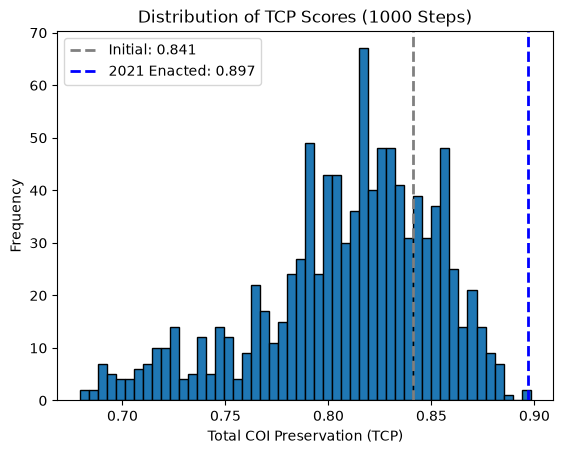

In [14]:
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
score_2021 = enacted_2021["tcp_score"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["ir"]
score_2021 = enacted_2021["ir"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

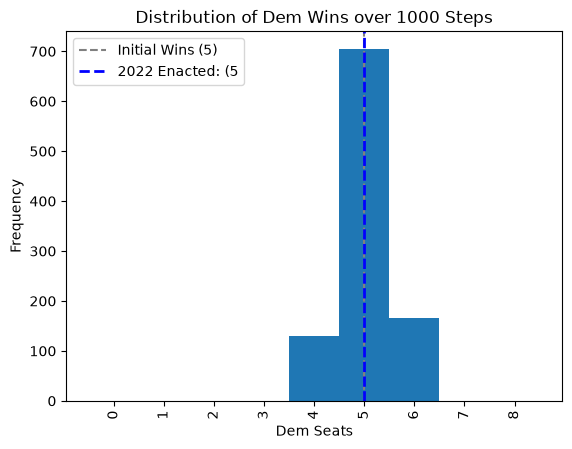

In [15]:
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2021 = count_dem_wins(enacted_2021)

plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x = wins_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2021}",
)

plt.xticks(rotation = 'vertical')
plt.legend()
plt.show()

In [16]:
'''
corr_coef, p_value = pearsonr(tcp_scores, ir_scores)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

sns.regplot(x=tcp_scores, y=ir_scores, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")

plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
plt.xlabel("TCP Scores")
plt.ylabel("IR Scores")

plt.show()
'''

'\ncorr_coef, p_value = pearsonr(tcp_scores, ir_scores)\n\nsns.set_theme(style="whitegrid")\nplt.figure(figsize=(7, 5))\n\nsns.regplot(x=tcp_scores, y=ir_scores, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")\n\nplt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)\nplt.xlabel("TCP Scores")\nplt.ylabel("IR Scores")\n\nplt.show()\n'

In [17]:
print(calculate_ir(best_map))

0.8970067304077158


In [18]:
print(calculate_ir(worst_map))

0.7469987340245876


In [19]:
print(calculate_ir(enacted_2021))

0.7382803834654411
